# 1. Setup and upload data

In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [234]:
path = 'default credit.csv'

df = pd.read_csv(path)
df 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,BILL_AMT_avg,BILL_AMT_trend,credit utilization ratio
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,1284.000000,3913,0.195650
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,2846.166667,-579,0.022350
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,16942.166667,13690,0.324878
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,38555.666667,17443,0.939800
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,18223.166667,-10514,0.172340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,1,3,1,39,0,0,0,0,0,...,8500,20000,5003,3047,5000,1000,0,120891.500000,172968,0.858855
29961,150000,1,3,2,43,-1,-1,-1,-1,0,...,1837,3526,8998,129,0,0,0,3530.333333,1683,0.011220
29962,30000,1,2,2,37,4,3,2,-1,0,...,0,0,22000,4200,2000,3100,1,11749.333333,-15792,0.118833
29963,80000,1,3,1,41,1,-1,0,0,0,...,85900,3409,1178,1926,52964,1804,1,44435.166667,-50589,-0.020563


# 2. Feature Engineering

In [235]:
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
con_features = ['AGE', 'LIMIT_BAL', 'BILL_AMT_avg', 'BILL_AMT_trend', 'credit utilization ratio',
                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
target = 'default payment next month'

In [236]:
# log transformation for right-skewed data
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

skewed_nonneg = ['AGE', 'LIMIT_BAL'] + [f'PAY_AMT{i}' for i in range(1, 7)]
skewed_signed = ['BILL_AMT_avg', 'credit utilization ratio']  

for col in skewed_nonneg:
    df[col] = np.log1p(df[col])
for col in skewed_signed:
    df[col] = signed_log1p(df[col])

In [237]:
X = df[cat_features + con_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Training

In [238]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

0.7472050725846822

In [239]:
# Get probability estimates for the test set
probabilities = model.predict_proba(X_test_scaled)

# Display the probability estimates
for i, prob in enumerate(probabilities):
    print(f"Sample {i+1}: Class 0 Probability = {prob[0]:.4f}, Class 1 Probability = {prob[1]:.4f}")

Sample 1: Class 0 Probability = 0.5717, Class 1 Probability = 0.4283
Sample 2: Class 0 Probability = 0.8080, Class 1 Probability = 0.1920
Sample 3: Class 0 Probability = 0.5521, Class 1 Probability = 0.4479
Sample 4: Class 0 Probability = 0.6431, Class 1 Probability = 0.3569
Sample 5: Class 0 Probability = 0.6476, Class 1 Probability = 0.3524
Sample 6: Class 0 Probability = 0.5372, Class 1 Probability = 0.4628
Sample 7: Class 0 Probability = 0.5785, Class 1 Probability = 0.4215
Sample 8: Class 0 Probability = 0.6863, Class 1 Probability = 0.3137
Sample 9: Class 0 Probability = 0.3550, Class 1 Probability = 0.6450
Sample 10: Class 0 Probability = 0.6965, Class 1 Probability = 0.3035
Sample 11: Class 0 Probability = 0.4183, Class 1 Probability = 0.5817
Sample 12: Class 0 Probability = 0.7191, Class 1 Probability = 0.2809
Sample 13: Class 0 Probability = 0.5817, Class 1 Probability = 0.4183
Sample 14: Class 0 Probability = 0.3380, Class 1 Probability = 0.6620
Sample 15: Class 0 Probabilit

/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# 4. Evaluation

In [240]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4673
           1       0.45      0.62      0.52      1320

    accuracy                           0.75      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.75      0.76      5993



/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leh20/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


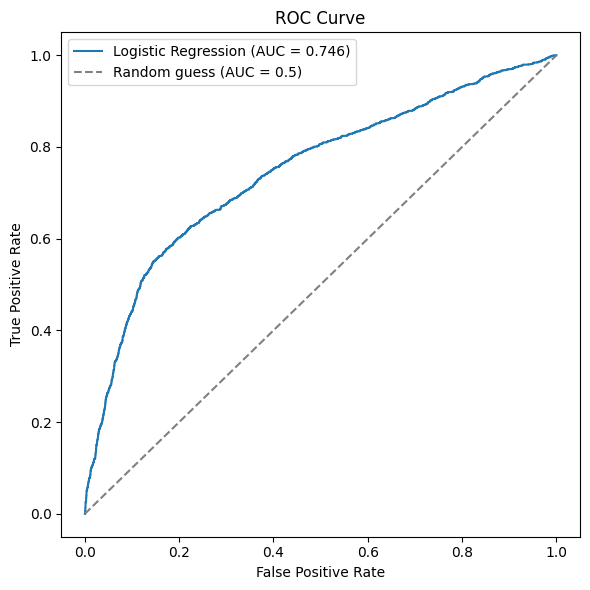

In [241]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()